### Clustering with Bank Transaction Data

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('bank_transactions.csv')

In [4]:
df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10-01-1994,F,JAMSHEDPUR,17819.05,02-08-2016,143207,25.0
1,T2,C2142763,04-04-1957,M,JHAJJAR,2270.69,02-08-2016,141858,27999.0
2,T3,C4417068,26-11-1996,F,MUMBAI,17874.44,02-08-2016,142712,459.0
3,T4,C5342380,14-09-1973,F,MUMBAI,866503.21,02-08-2016,142714,2060.0
4,T5,C9031234,24-03-1988,F,NAVI MUMBAI,6714.43,02-08-2016,181156,1762.5


In [5]:
df.set_index('TransactionID', inplace=True)

In [6]:
df.head()

,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
TransactionID,,,,,,,,
T1,C5841053,10-01-1994,F,JAMSHEDPUR,17819.05,02-08-2016,143207,25.0
T2,C2142763,04-04-1957,M,JHAJJAR,2270.69,02-08-2016,141858,27999.0
T3,C4417068,26-11-1996,F,MUMBAI,17874.44,02-08-2016,142712,459.0
T4,C5342380,14-09-1973,F,MUMBAI,866503.21,02-08-2016,142714,2060.0
T5,C9031234,24-03-1988,F,NAVI MUMBAI,6714.43,02-08-2016,181156,1762.5


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, T1 to T20000
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               20000 non-null  object 
 1   CustomerDOB              19928 non-null  object 
 2   CustGender               19989 non-null  object 
 3   CustLocation             19999 non-null  object 
 4   CustAccountBalance       19973 non-null  float64
 5   TransactionDate          20000 non-null  object 
 6   TransactionTime          20000 non-null  int64  
 7   TransactionAmount (INR)  20000 non-null  float64
dtypes: float64(2), int64(1), object(5)
memory usage: 1.4+ MB


In [8]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d-%m-%Y')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, T1 to T20000
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CustomerID               20000 non-null  object        
 1   CustomerDOB              19928 non-null  object        
 2   CustGender               19989 non-null  object        
 3   CustLocation             19999 non-null  object        
 4   CustAccountBalance       19973 non-null  float64       
 5   TransactionDate          20000 non-null  datetime64[ns]
 6   TransactionTime          20000 non-null  int64         
 7   TransactionAmount (INR)  20000 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 1.4+ MB


In [10]:
df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], format='%d-%m-%Y', errors='coerce')

In [11]:
mv = df.isnull().sum()
mv[mv>0]

CustomerDOB           1362
CustGender              11
CustLocation             1
CustAccountBalance      27
dtype: int64

Let's drop all missing values rows.

In [12]:
df.dropna(inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18606 entries, T1 to T20000
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CustomerID               18606 non-null  object        
 1   CustomerDOB              18606 non-null  datetime64[ns]
 2   CustGender               18606 non-null  object        
 3   CustLocation             18606 non-null  object        
 4   CustAccountBalance       18606 non-null  float64       
 5   TransactionDate          18606 non-null  datetime64[ns]
 6   TransactionTime          18606 non-null  int64         
 7   TransactionAmount (INR)  18606 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(3)
memory usage: 1.3+ MB


In [14]:
df.columns = df.columns[:-1].to_list()+['TransactionAmount']
df.columns

Index(['CustomerID', 'CustomerDOB', 'CustGender', 'CustLocation',
       'CustAccountBalance', 'TransactionDate', 'TransactionTime',
       'TransactionAmount'],
      dtype='object')

In [15]:
df.head()

,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount
TransactionID,,,,,,,,
T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0
T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0
T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0
T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.0
T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5


In [16]:
df = df.loc[:,['CustGender','CustAccountBalance','TransactionAmount']]

In [17]:
df.head()

,CustGender,CustAccountBalance,TransactionAmount
TransactionID,,,
T1,F,17819.05,25.0
T2,M,2270.69,27999.0
T3,F,17874.44,459.0
T4,F,866503.21,2060.0
T5,F,6714.43,1762.5


In [18]:
df = pd.get_dummies(df, drop_first=True)

In [19]:
df.head()

,CustAccountBalance,TransactionAmount,CustGender_M
TransactionID,,,
T1,17819.05,25.0,False
T2,2270.69,27999.0,True
T3,17874.44,459.0,False
T4,866503.21,2060.0,False
T5,6714.43,1762.5,False


## Let's build the model

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [20]:
em_score = {}
sh_score = {}

In [22]:
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df)
    em_score[k] = km.inertia_
    sh_score[k] = silhouette_score(df, km.labels_)

In [23]:
em_score

{2: 3713388196263754.5,
 3: 2375578205332104.5,
 4: 1072574646336827.8,
 5: 668723637579593.2,
 6: 480388883794697.9,
 7: 349842729864570.1,
 8: 298308332445549.0,
 9: 196425142618643.38}

In [26]:
sh_score

{2: np.float64(0.9917851616782603),
 3: np.float64(0.9553475242353725),
 4: np.float64(0.9443438285059021),
 5: np.float64(0.9006897312811741),
 6: np.float64(0.9006719852514444),
 7: np.float64(0.869612593114232),
 8: np.float64(0.8891922414827509),
 9: np.float64(0.8350147983182014)}

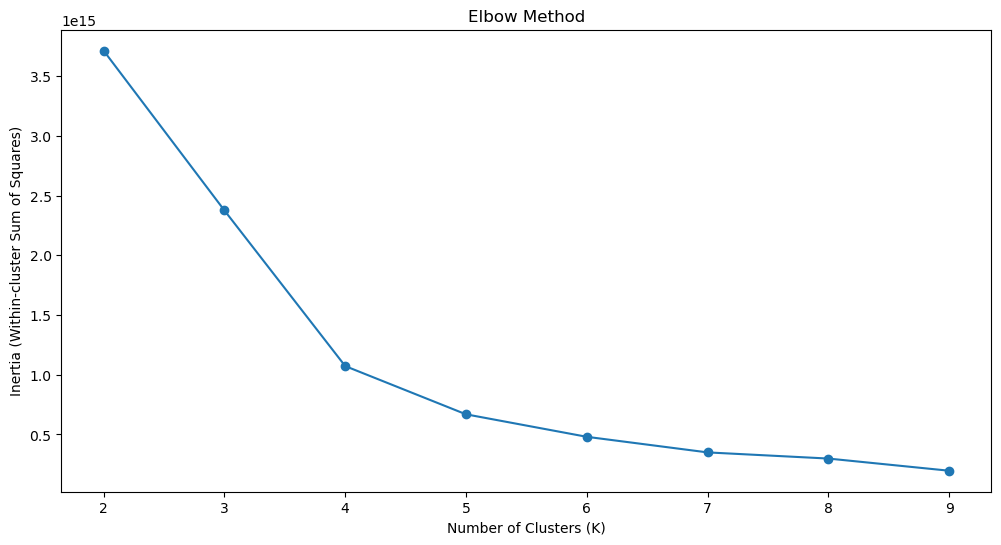

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(em_score.keys(), em_score.values(), marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('Elbow Method')
plt.show()

In [39]:
km = KMeans(n_clusters=3, random_state=42)
km.fit(df)

KMeans(n_clusters=3, random_state=42)

In [40]:
df['cluster'] = km.labels_

In [41]:
df.head()

,CustAccountBalance,TransactionAmount,CustGender_M,cluster
TransactionID,,,,
T1,17819.05,25.0,False,0
T2,2270.69,27999.0,True,0
T3,17874.44,459.0,False,0
T4,866503.21,2060.0,False,0
T5,6714.43,1762.5,False,0


## Viewing the clusters

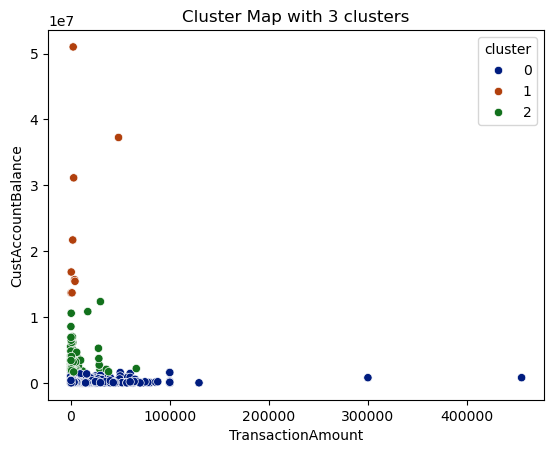

In [44]:
sns.scatterplot(data=df, x='TransactionAmount',y = 'CustAccountBalance', hue='cluster', palette='dark')
plt.title("Cluster Map with 3 clusters")
plt.show()


In [43]:
df.cluster.value_counts()

cluster
0    18460
2      137
1        9
Name: count, dtype: int64

ValueError: Unsupported dtype object

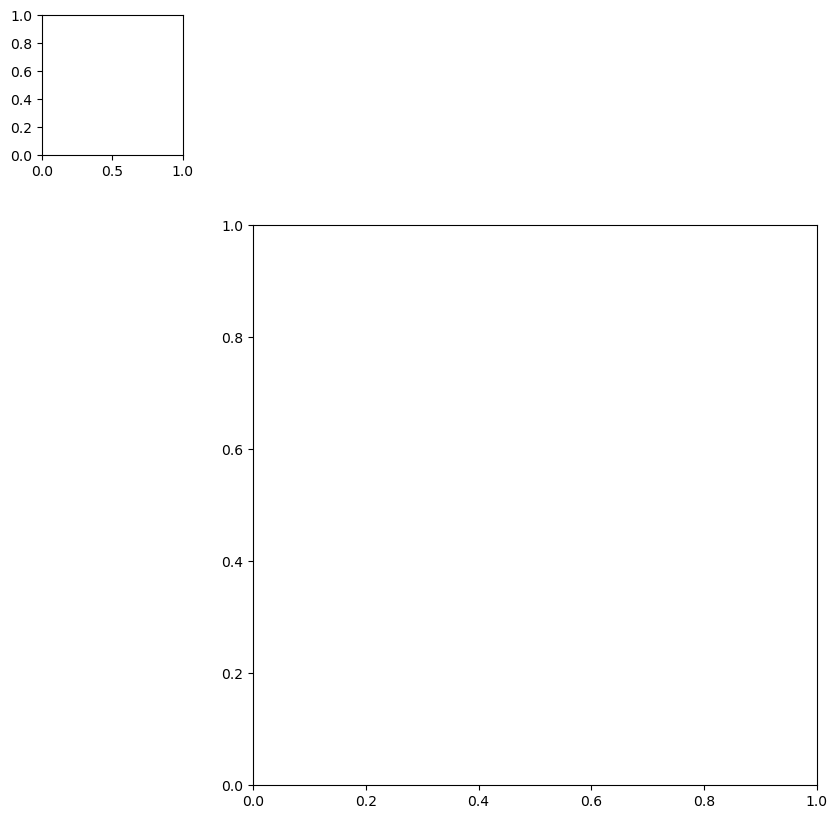

In [52]:
cg = sns.clustermap(df.iloc[:200,:-1], col_cluster=False)
plt.title("Dendrogram")
plt.show()

In [47]:
pip install fastcluster

Note: you may need to restart the kernel to use updated packages.


In [48]:
import fastcluster
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

In [55]:
# fastcluster linkage
Z = fastcluster.linkage_vector(df.iloc[:30, :-1], method='ward')

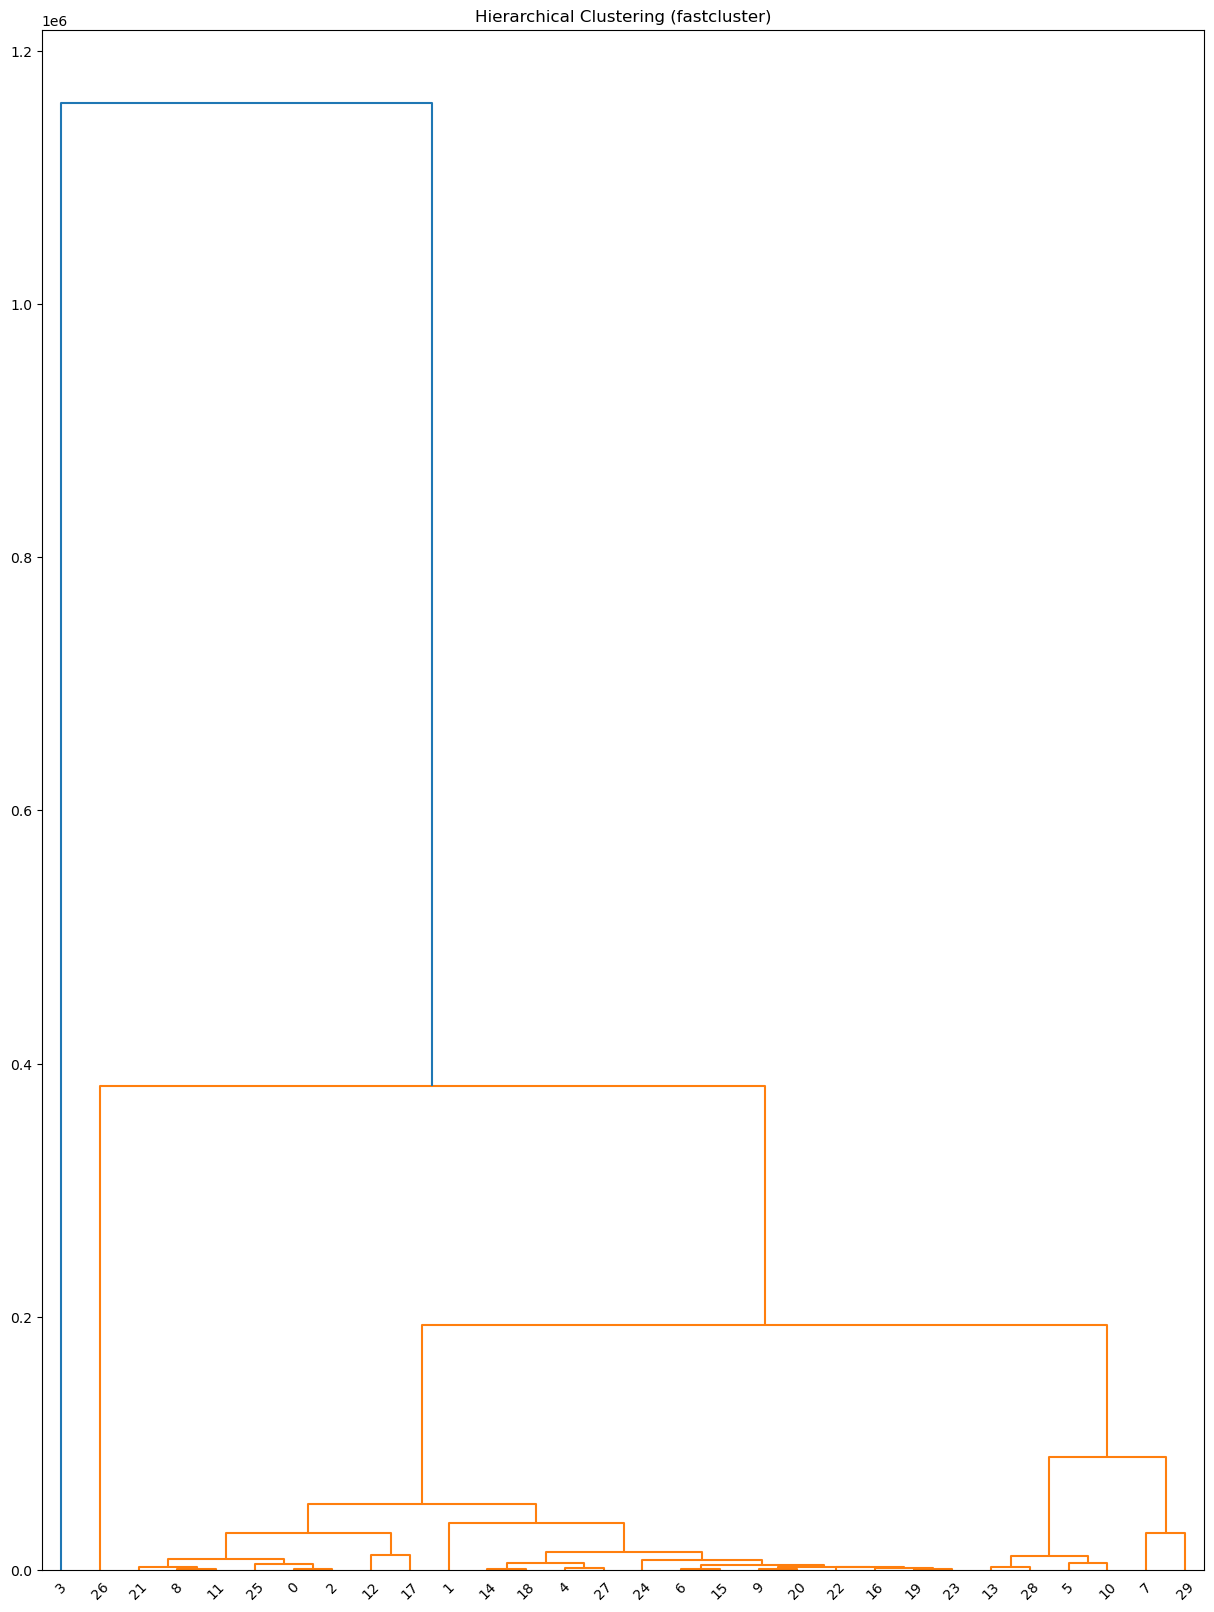

In [56]:
plt.figure(figsize=(15,20))
dendrogram(Z)
plt.title("Hierarchical Clustering (fastcluster)")
plt.show()

In [60]:
df.iloc[[14,18],:]

,CustAccountBalance,TransactionAmount,CustGender_M,cluster
TransactionID,,,,
T15,10100.84,338.0,True,0
T20,10643.50,945.0,True,0
